# Train and Fine-Tune XGBRegressor for Trip Duration Prediction
This notebook loads the engineered features, fine-tunes XGBRegressor, and evaluates its performance.

In [27]:
# Import libraries
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [28]:
# Load features and target
X = pd.read_csv('X_features_duration.csv')
y = pd.read_csv('y_target_duration.csv')['duration_minutes']

In [29]:
# Just use random split for now - it's easier and still valid
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
# Define XGBRegressor and hyperparameter grid
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 8, 10],
    "learning_rate": [0.05, 0.1, 0.15],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 1.5]
}

In [31]:
# Grid search for best hyperparameters
grid_search = GridSearchCV(
    xgb, param_grid, cv=3, scoring="neg_mean_absolute_error", 
    verbose=2, n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

# Retrain with validation set for monitoring
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

final_model = XGBRegressor(**grid_search.best_params_, random_state=42, early_stopping_rounds=20,    eval_metric='mae'          # Add evaluation metric
  # Move here
)
final_model.fit(
    X_train_split, y_train_split,
    eval_set=[(X_val, y_val)],
    verbose=False
)


Fitting 3 folds for each of 432 candidates, totalling 1296 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.9; total time=   1.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, reg_alpha=0, reg_lambda=1.5, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   1.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, reg_alpha=0, reg_lambda=1.5, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   1.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   1.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimato

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'mae'


In [32]:
import numpy as np
# Evaluate on test set
y_pred = final_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
# 1. Calculate the Mean Squared Error (MSE) first
mse = mean_squared_error(y_test, y_pred)

# 2. Then, take the square root to get the RMSE
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Test MAE: {mae:.2f} minutes")
print(f"Test RMSE: {rmse:.2f} minutes")
print(f"Test R2: {r2:.3f}")

Test MAE: 16.91 minutes
Test RMSE: 30.58 minutes
Test R2: 0.396


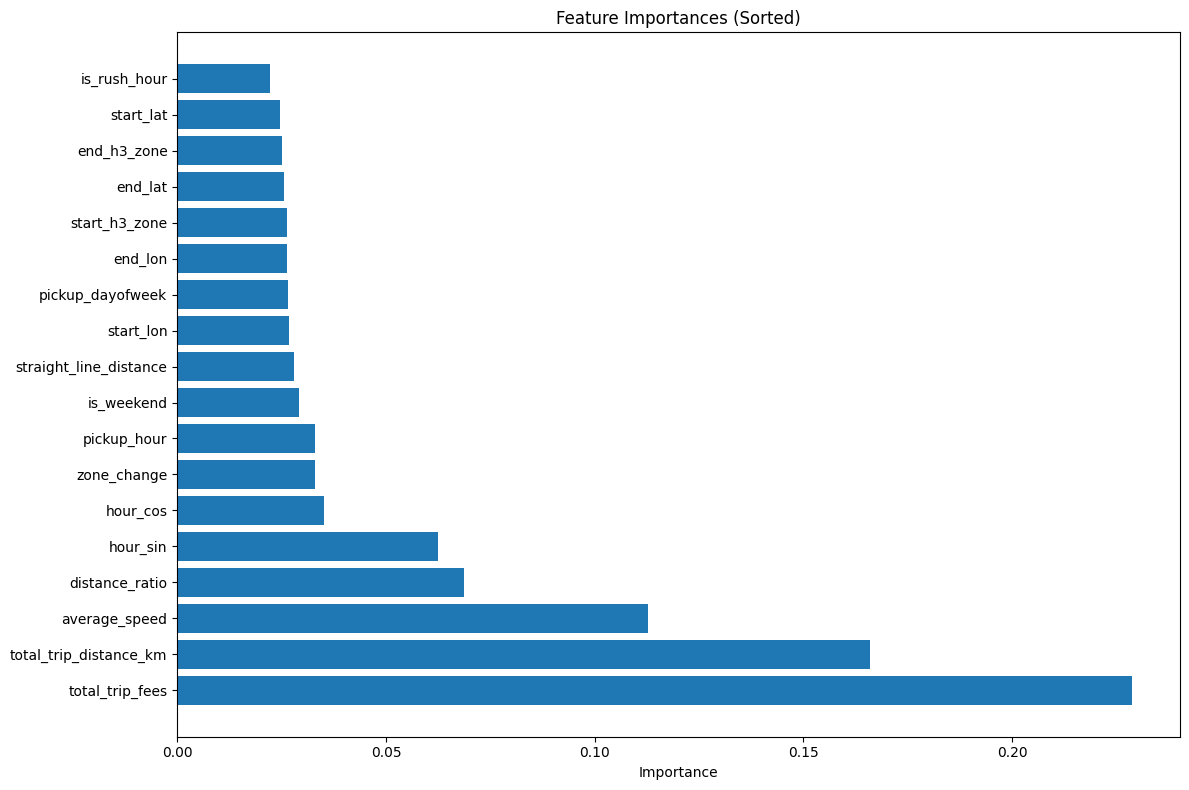


Top 5 most important features:
total_trip_fees: 0.2288
total_trip_distance_km: 0.1658
average_speed: 0.1128
distance_ratio: 0.0686
hour_sin: 0.0624


In [33]:
# Feature importance plot
importances = final_model.feature_importances_
feat_names = X.columns
# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.title("Feature Importances (Sorted)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 5 most important features:")
for i in range(min(5, len(indices))):
    print(f"{feat_names[indices[i]]}: {importances[indices[i]]:.4f}")

In [ ]:
import joblib

# Assume 'final_model' is your trained XGBoost, scikit-learn, or similar model
# This is the line that saves your model to a file
joblib.dump(final_model, 'duration_model.joblib')

print("Model saved successfully!")

Model saved successfully!


: 

In [34]:
import joblib

joblib.dump(best_xgb, 'best_xgb_model_duration.pkl')

NameError: name 'best_xgb' is not defined